## Дисклеймер!!!!!

Поскольку я терпеть ненавижу отвратно структурированный код, я большую часть инжиринга признаков вынес в отдельный файл. Направление действий будет видно как и указано в задании, но сразу для всего. Я не писал всё одним батчем, тут положена куча коммитов, просто для сохранения ясности я решил не сваливать всё в одну нечитабельную кучу. 

По поводу баллов - претендую на баллы за каждый из указанныз в ДЗ пунктов

## Грузим данные

Из основных фич которые я выделил за это время:

1) Количество добавлений в корзину/поисков/просмотров
2) "Вероятность" добавления в корзину при наличии клика по товару
3) Статистики по количествуй действий за каждую сессию (40 минут)
4) Последние 3/2/1 действия(е)
5) TFIDF + SVD по тексту поиска
6) Флаги на запросы по самым популярным продуктам питания
7) Количество уникальных запросов
8) Статистики по длине запроса в словах/символях (медианная, максимальная, средняя)
9) Последний запрос, его длина в символах и словах
10) Средняя/максимальная/минимальная цена просмотренного товара
11) Доля товаров купленных по скидке
12) Среднее значение скидки
13) Доля наиболее частой категории товаров

+ все признаки которые были в преложенном решении

### UPD
Добавил в `embedding_features` колонку-список эмбеддингов поиска TFIDF+SVD, результат только ухудшился (примерно на 0.002)

In [1]:
from data_preparation import OzonDataFormer
from datetime import date

In [2]:
former = OzonDataFormer()

In [3]:
former.fit_text_vectorizer(feature_end_date=date(2024, 5, 31))

In [4]:
data_params = {
    'include_actions': True,
    'include_search': True,
    'include_price': True,
    'group_embedding_features': False
}

In [5]:
train_df = former.construct_dataset(
    feature_end_date=date(2024, 5, 31),
    target_start_date=date(2024, 6, 1),
    target_end_date=date(2024, 6, 30),
    **data_params
)

In [6]:
val_df = former.construct_dataset(
    feature_end_date=date(2024, 6, 30),
    target_start_date=date(2024, 7, 1),
    target_end_date=date(2024, 7, 31),
    **data_params
)

In [7]:
X_train = train_df.drop(columns=['user_id', 'target'])
y_train = train_df['target']

In [8]:
X_val = val_df.drop(columns=['user_id', 'target'])
y_val = val_df['target']

In [9]:
from utils2 import AutoFeatureStandardizer

In [10]:
standardizer = AutoFeatureStandardizer()

In [11]:
X_train = standardizer.fit_transform(X_train)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [12]:
X_val = standardizer.transform(X_val)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

## Проверка адекватности разделения на тренировку и валидацию

In [13]:
import numpy as np

In [14]:
cat_features = list(X_train.select_dtypes('category').columns)

In [15]:
embedding_features = ['search_emb'] if 'search_emb' in X_train.columns else None

In [16]:
from catboost.utils import get_gpu_device_count

if get_gpu_device_count() > 0:
    task_type = 'GPU'
else:
    task_type = 'CPU'

params = {
    'iterations': 100,
    'depth': 7,
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': task_type,
    'cat_features': cat_features,
    'embedding_features': embedding_features
}

# search_tfidfsvd

In [ ]:
from validation_check import get_train_val_difference

diff_score, _, _ = get_train_val_difference(X_train, y_train, X_val, y_val, params)

In [ ]:
diff_score

0.7104334306389241

Скор получился примерно 0.78. Ну выглядит вроде адекватно учитывая что в данных очевидно есть временная зависимость

### UPD
Периодически при добавлении новых признаков скор менялся от 0.7 до 0.85. Всё ещё норм, опять же дрифт временных данных тут играет свою роль.

## Обучение модели


Скор - 0.81949

In [ ]:
from catboost import CatBoostClassifier, Pool

In [ ]:
train_pool = Pool(
    X_train,
    label=y_train,
    cat_features=params.get('cat_features'),
    embedding_features=params.get('embedding_features')
)

val_pool = Pool(
    X_val,
    label=y_val,
    cat_features=params.get('cat_features'),
    embedding_features=params.get('embedding_features')
)

In [ ]:
params['iterations'] = 5000

model = CatBoostClassifier(**params)

In [ ]:
model_name = "models/less_weird2.bin"

try:
    model.load_model(model_name)
except Exception:
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
    model.save_model(model_name)

Learning rate set to 0.199979
0:	learn: 0.6358755	test: 0.6330824	best: 0.6330824 (0)	total: 339ms	remaining: 5m 38s
10:	learn: 0.5391990	test: 0.5317614	best: 0.5317614 (10)	total: 2.95s	remaining: 4m 24s
20:	learn: 0.5354892	test: 0.5289337	best: 0.5288702 (19)	total: 5.57s	remaining: 4m 19s
30:	learn: 0.5342650	test: 0.5280403	best: 0.5280403 (30)	total: 8.24s	remaining: 4m 17s
40:	learn: 0.5334134	test: 0.5278215	best: 0.5277367 (38)	total: 10.8s	remaining: 4m 12s
50:	learn: 0.5329090	test: 0.5274523	best: 0.5274523 (50)	total: 13.4s	remaining: 4m 8s
60:	learn: 0.5324537	test: 0.5272474	best: 0.5272324 (56)	total: 15.8s	remaining: 4m 3s
70:	learn: 0.5320433	test: 0.5270582	best: 0.5270582 (70)	total: 18.5s	remaining: 4m 1s
80:	learn: 0.5316370	test: 0.5269718	best: 0.5269718 (80)	total: 21.2s	remaining: 4m
90:	learn: 0.5312275	test: 0.5269236	best: 0.5268650 (84)	total: 23.8s	remaining: 3m 58s
100:	learn: 0.5308648	test: 0.5267076	best: 0.5267076 (100)	total: 26.4s	remaining: 3m 54

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

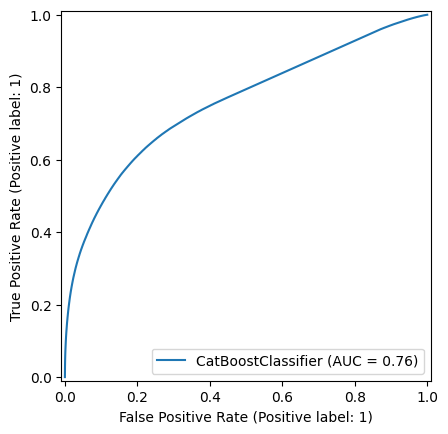

In [ ]:
RocCurveDisplay.from_estimator(model, X_val, y_val)

## Интерпретация модели

In [ ]:
from utils2 import AutoFeatureStandardizer, BinaryClassifierInterpreter
from cluster_compare import NotebookBinaryClusterInterpreter
from bokeh.io import output_notebook

In [ ]:
import panel as pn
pn.extension()

In [ ]:
output_notebook()

tool = NotebookBinaryClusterInterpreter(
    X=X_train.loc[::30],
    y=y_train.loc[::30],
)
tool.show()

Loading BokehJS ...

/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


BokehModel(combine_events=True, render_bundle={'docs_json': {'9a3f09e3-917b-47eb-a219-a6e91af3a144': {'version…

А выглядит интересно, чётко видны 2 кластера, надо посмотреть чё там такое.

### UPD
Я добавил соотношение меток классов к кластерам, получается интересная картина. В левом кластере оба класса представлены $\pm$ одинаково, а во втором соотношение примерно 50/50. Мб имеет смысл использовать результаты кластеризации как признаки для модели, но надо хорошо подумать над алгоритмом кластеризации

### UPD 2
Я добавил SHAP, к сожалению никаких особых откровений. По большому счёту - разделение пользователей по активности.

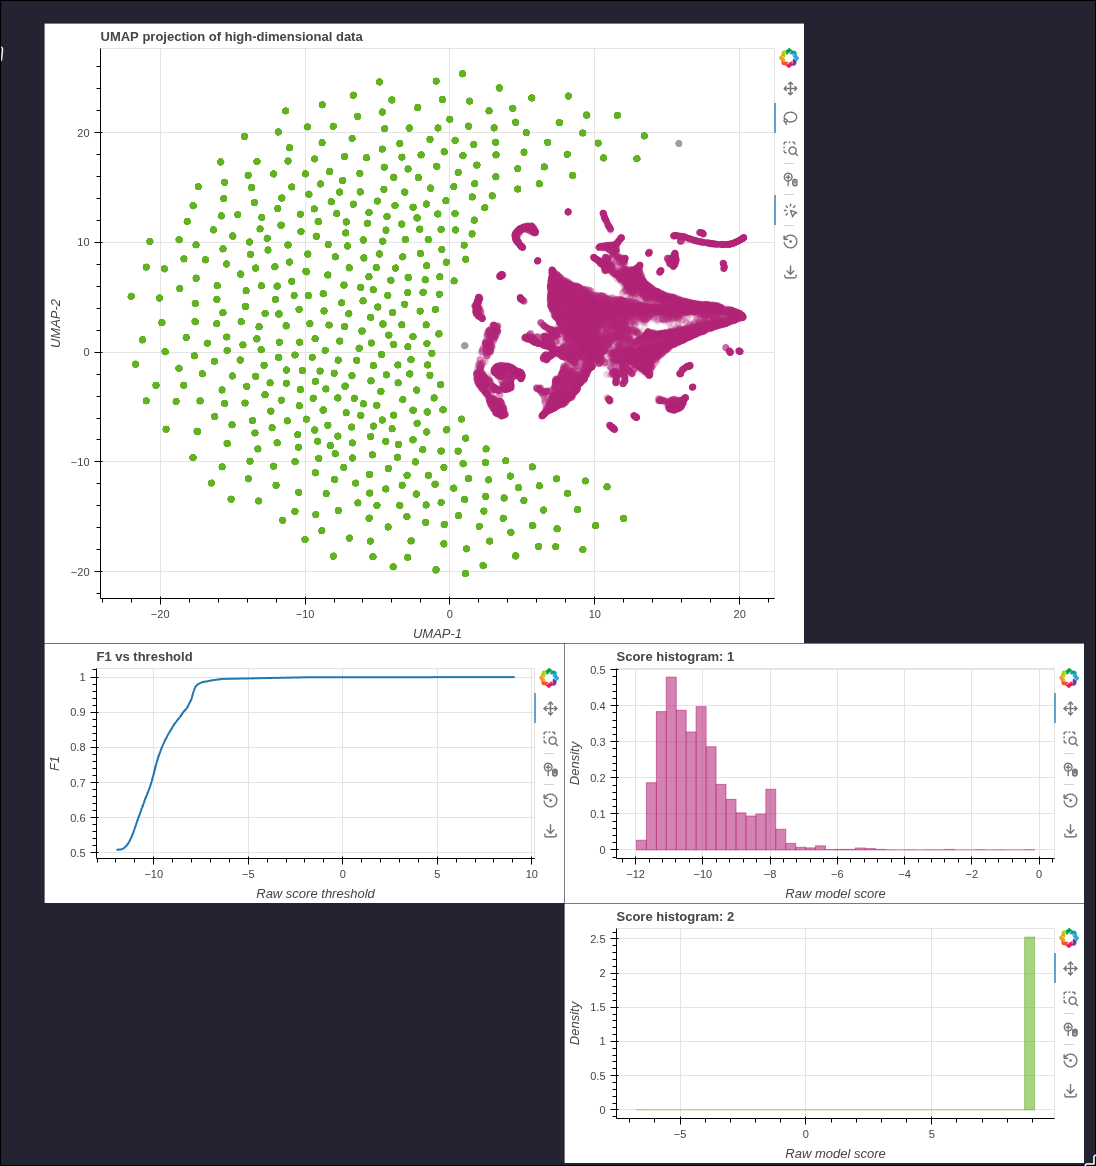

In [ ]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train[::30], y_train[::30]),
    val=(X_val[::10], y_val[::10]),
    model=model
)

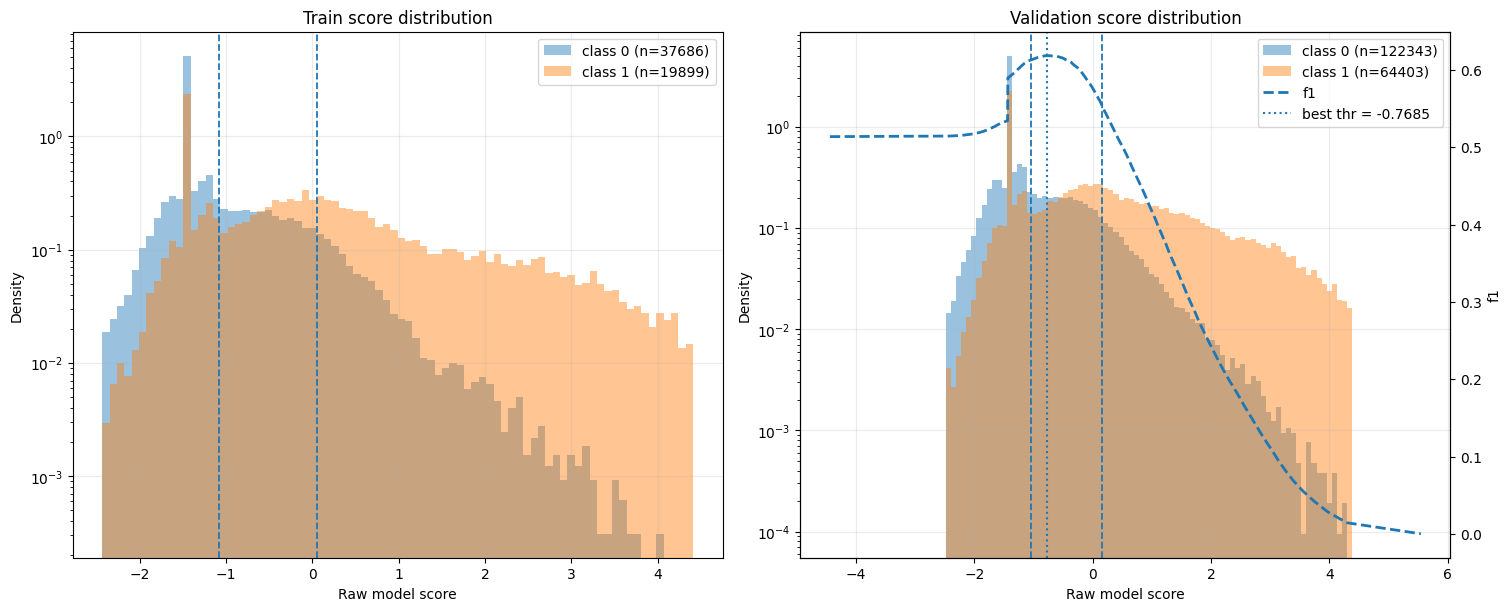

In [ ]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

In [ ]:
interpreter.plot_float_feature_histograms()

In [ ]:
interpreter.plot_score_feature_contours()

In [ ]:
# interpreter.plot_shap_beeswarm(sample_frac=0.1)

ExplainerError: Currently TreeExplainer can only handle models with categorical splits when feature_perturbation="tree_path_dependent" and no background data is passed. Please try again using shap.TreeExplainer(model, feature_perturbation="tree_path_dependent").

## Тюнинг параметров


Скор - 0.82092

In [ ]:
do_tune = False

In [ ]:
import optuna
from sklearn.metrics import roc_auc_score

In [ ]:
def objective(trial: optuna.Trial):
    eta = trial.suggest_float("eta", 1e-3, 10.0, log=True)
    depth = trial.suggest_int("depth", 1, 16)
    
    params['eta'] = eta
    params['depth'] = depth
        
    model = CatBoostClassifier(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=False,
        early_stopping_rounds=50,
    )

    preds = model.predict_proba(X_val)[:, 1]
    
    score = roc_auc_score(y_val, preds)
    return score

In [ ]:
if do_tune:
    study = optuna.create_study(direction='maximize')
    params['iterations'] = 500
    study.optimize(objective, n_trials=100)
    
    from optuna.visualization import plot_contour
    from plotly.io import show
    
    fig = plot_contour(study)

    show(fig)
    
    best_params = study.best_params
else:
    best_params = {'eta': 0.055848570897405615, 'depth': 8}

Лучшие параметры - {'eta': 0.055848570897405615, 'depth': 8}

In [ ]:
params.update(best_params)
params['iterations'] = 5000

## Финальное предсказание

In [ ]:
model = CatBoostClassifier(**params)

model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
model.save_model(model_name)

In [ ]:
test_df = former.construct_dataset(
    feature_end_date=date(2024, 7, 31),
    users_df=former.test_users_submission,
    **data_params
)

In [ ]:
X_test = test_df.drop(columns='user_id')

In [ ]:
X_test_s = standardizer.transform(X_test)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1266: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [ ]:
predict = model.predict(X_test_s, prediction_type='Probability')

In [ ]:
test_df['predict'] = predict[:, 1]
test_df[['user_id', 'predict']].to_csv('overfitted_ahh.csv', index=False)